<a href="https://colab.research.google.com/github/njwbilll/Tugas-4_Practical-Statistics-for-Data-Scientists-O-Reilly_Najwa-Bilqis-Al-Khalidah/blob/main/06_Statistical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Statistical Machine Learning

**Referensi:** Practical Statistics for Data Scientists (Peter Bruce, Andrew Bruce, Peter Gedeck)

***

## Ringkasan Chapter

Bab ini menjembatani transisi dari pemodelan statistik klasik menuju teknik machine learning algoritmik. Jika statistik tradisional seperti regresi linear sangat peduli pada inferensi, pengujian hipotesis, dan interpretasi matematis, machine learning modern lebih berfokus murni pada optimasi akurasi prediksi.

Kita akan mengeksplorasi algoritma berbasis jarak sederhana hingga arsitektur ensemble kompleks yang membangun ratusan pohon keputusan sekaligus. Algoritma-algoritma ini menjadi standar industri karena kemampuannya menangkap pola non-linear rumit tanpa memerlukan asumsi distribusi data yang kaku.

### Topik yang Dibahas:
1. K-Nearest Neighbors (KNN)
2. Tree Models (Pohon Keputusan)
3. Bagging dan Random Forest
4. Boosting (Gradient Boosting)


***
## Setup: Import Library

Kita memuat modul manipulasi data, visualisasi, alat prapemrosesan, dan beberapa kelas algoritma machine learning dari scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Modul Statistical Machine Learning berhasil dimuat.")


Modul Statistical Machine Learning berhasil dimuat.


***
## 1. K-Nearest Neighbors (KNN)

### Penjelasan Teori

K-Nearest Neighbors adalah salah satu algoritma paling intuitif dalam machine learning. Konsep dasarnya berbunyi: observasi yang memiliki karakteristik serupa akan cenderung berada di lokasi yang berdekatan dalam ruang fitur geometris. Saat memprediksi label untuk data baru, algoritma ini mencari sejumlah K observasi terdekat dari data pelatihan, lalu mengambil suara terbanyak (majority vote) dari label tetangga tersebut.

Terdapat dua syarat mutlak sebelum menggunakan KNN. Pertama, kita harus menentukan metrik jarak, biasanya Jarak Euclidean. Kedua, karena KNN mengukur jarak absolut, semua fitur numerik wajib distandarisasi (diskalakan) agar variabel dengan rentang nilai jutaan (seperti pendapatan) tidak mendominasi variabel dengan rentang nilai kecil (seperti usia).

In [2]:
# Simulasi Data Prediksi Churn Pelanggan
np.random.seed(42)
n_samples = 1000

# Membuat fitur independen
umur = np.random.normal(40, 12, n_samples)
saldo = np.random.normal(50000, 20000, n_samples)
skor_aktivitas = np.random.normal(50, 15, n_samples)

# Rumus logika tersembunyi untuk menentukan target Churn
prob_churn = (umur * 0.02) - (saldo * 0.00001) - (skor_aktivitas * 0.03) + 1.5
prob_churn = 1 / (1 + np.exp(-prob_churn)) # Sigmoid untuk merubah ke probabilitas
churn_target = np.where(prob_churn > 0.5, 1, 0)

df_ml = pd.DataFrame({'Umur': umur, 'Saldo': saldo, 'Skor_Aktivitas': skor_aktivitas, 'Churn': churn_target})

# Pemisahan Latih dan Uji
X = df_ml[['Umur', 'Saldo', 'Skor_Aktivitas']]
y = df_ml['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standarisasi Fitur sangat penting untuk KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inisialisasi dan melatih model KNN dengan tetangga K=5
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

prediksi_knn = model_knn.predict(X_test_scaled)
print(f"Akurasi KNN (K=5): {accuracy_score(y_test, prediksi_knn) * 100:.2f} persen")


Akurasi KNN (K=5): 95.33 persen


***
## 2. Tree Models (Pohon Keputusan)

### Penjelasan Teori

Model Pohon Keputusan (Decision Tree) menyelesaikan masalah klasifikasi dengan serangkaian aturan biner (ya atau tidak). Algoritma ini secara rekursif membelah ruang data menjadi persegi panjang bersarang. Pada setiap titik percabangan, algoritma mengevaluasi semua fitur yang ada dan memilih batas pemotongan yang menghasilkan cabang paling murni (homogen) berdasarkan metrik Gini Impurity atau Entropy.

Kelebihan utama dari pohon keputusan adalah kemudahan interpretabilitas. Kita bisa menelusuri logika pengambilan keputusannya persis seperti diagram alur manusia. Model ini juga sangat kebal terhadap outlier dan tidak memerlukan standarisasi data.

Akurasi Pohon Keputusan: 89.33 persen


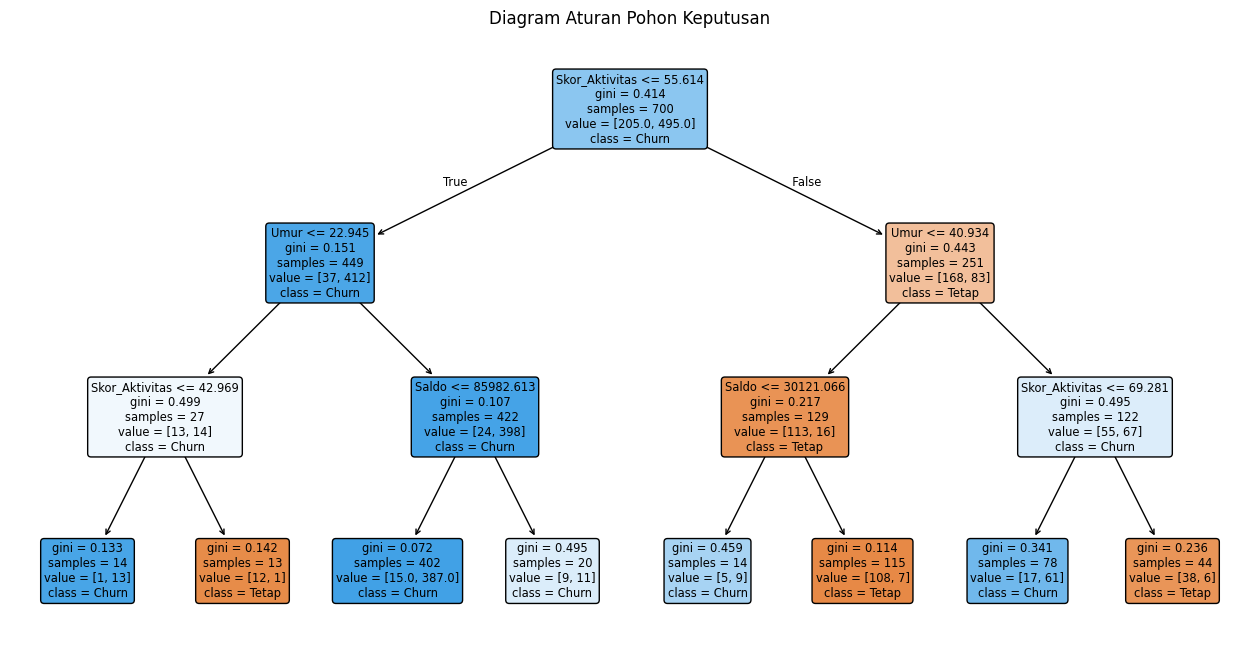

In [3]:
# Melatih model Decision Tree
# Membatasi max_depth agar pohon tidak tumbuh terlalu dalam (mencegah overfitting)
model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

prediksi_tree = model_tree.predict(X_test)
print(f"Akurasi Pohon Keputusan: {accuracy_score(y_test, prediksi_tree) * 100:.2f} persen")

# Visualisasi struktur pohon
plt.figure(figsize=(16, 8))
plot_tree(model_tree, feature_names=X.columns, class_names=['Tetap', 'Churn'], filled=True, rounded=True)
plt.title('Diagram Aturan Pohon Keputusan')
plt.show()


***
## 3. Bagging dan Random Forest

### Penjelasan Teori

Satu pohon keputusan tunggal cenderung sangat tidak stabil. Perubahan kecil pada data latih bisa mengubah struktur akar hingga ke bawah secara drastis. Fenomena ini disebut varians tinggi (high variance).

Random Forest mengatasi hal ini menggunakan teknik ensemble bernama Bagging (Bootstrap Aggregating). Model ini membangun ratusan pohon secara acak dan independen. Keacakan disuntikkan pada dua tingkat:
1. Setiap pohon dilatih pada sampel baris data yang berbeda yang diambil menggunakan metode bootstrap.
2. Setiap titik percabangan pada pohon tidak mempertimbangkan semua fitur, melainkan hanya sub-himpunan acak dari fitur yang tersedia.

Hasil tebakan akhirnya adalah rata-rata (untuk regresi) atau voting terbanyak (untuk klasifikasi) dari seluruh pohon. Metode ini sangat tangguh dan jarang mengalami overfitting.

Akurasi Random Forest: 94.33 persen


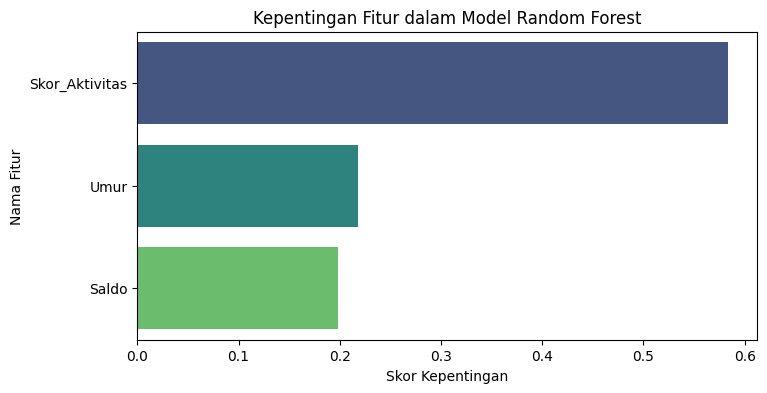

In [4]:
# Inisialisasi Random Forest dengan 100 pohon
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

prediksi_rf = model_rf.predict(X_test)
print(f"Akurasi Random Forest: {accuracy_score(y_test, prediksi_rf) * 100:.2f} persen")

# Ekstraksi tingkat kepentingan fitur
kepentingan_fitur = model_rf.feature_importances_
df_kepentingan = pd.DataFrame({'Fitur': X.columns, 'Kepentingan': kepentingan_fitur})
df_kepentingan = df_kepentingan.sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x='Kepentingan', y='Fitur', data=df_kepentingan, palette='viridis')
plt.title('Kepentingan Fitur dalam Model Random Forest')
plt.xlabel('Skor Kepentingan')
plt.ylabel('Nama Fitur')
plt.show()


***
## 4. Boosting (Gradient Boosting)

### Penjelasan Teori

Boosting adalah keluarga algoritma ensemble lainnya yang memiliki filosofi bertolak belakang dengan Random Forest. Alih-alih membangun pohon secara paralel dan independen, Boosting membangun pohon secara berurutan (sekuensial).

Pohon pertama dibangun dan dievaluasi. Pohon kedua kemudian dirancang secara khusus untuk memperbaiki kesalahan (residual) yang dibuat oleh pohon pertama. Pohon ketiga memperbaiki kesalahan pohon kedua, dan seterusnya. Hal ini membuat model belajar secara lambat (ditentukan oleh hyperparameter learning rate) namun sangat presisi.

Gradient Boosting adalah salah satu varian boosting yang paling banyak memenangkan kompetisi Kaggle karena mampu menekan error ke titik terendah secara matematis.

In [5]:
# Inisialisasi model Gradient Boosting
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train, y_train)

prediksi_gb = model_gb.predict(X_test)
print(f"Akurasi Gradient Boosting: {accuracy_score(y_test, prediksi_gb) * 100:.2f} persen")

# Membuat rangkuman performa perbandingan
hasil_perbandingan = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Akurasi': [
        accuracy_score(y_test, prediksi_knn),
        accuracy_score(y_test, prediksi_tree),
        accuracy_score(y_test, prediksi_rf),
        accuracy_score(y_test, prediksi_gb)
    ]
})

print("\nTabel Komparasi Akurasi Akhir:")
display(hasil_perbandingan.sort_values(by='Akurasi', ascending=False))


Akurasi Gradient Boosting: 95.00 persen

Tabel Komparasi Akurasi Akhir:


,Model,Akurasi
0,KNN,0.953333
3,Gradient Boosting,0.950000
2,Random Forest,0.943333
1,Decision Tree,0.893333
